# **Adaptative Grid** Test

In [1]:
# Import modules
from seislib import tomography as SeisLib_Tomo
from seislib.plotting import make_colorbar
from seislib import plotting
import seislib.utils as su

import matplotlib as mpl
import matplotlib.pyplot as plt

import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

import cartopy.crs as ccrs

import elevation
import os
from collections.abc import Iterable

import copy
import numpy as np
from scipy.interpolate import griddata
from scipy.io import savemat
from obspy.geodetics import gps2dist_azimuth

from glob import glob

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from dash import Dash, dcc, html, Input, Output
from jupyter_dash import JupyterDash

from socket import gethostname

# code and plot setup
# settings
pd.options.plotting.backend = "plotly"

## 0. Data loading

In [2]:
""" 
Creating a grid using the station list.
"""
## User parameters:
station_list =  "../notebooks/data/station_coords/2024_TLS_GM_Station_File_SPARSE.txt"

data_folder = '../notebooks/data/20_tomo_ANSWT/TOMO__2024_TLS_GM_SPARSE_v4__xcorr_50.0hz_coher/TT/MODE_0/PickGV_manual_all_dist/qc_all_dist'
output_file_name = data_folder + "/GroupVel_TT_MODE_0_3.00_try1.mat"

"""
Processing:
"""
# Read station file:
station_data = su.load_station_list(station_list)

# Minimum and maximum latitudes and longitudes:
cell_size = 0.03
if isinstance(cell_size, Iterable):
    dlon, dlat = cell_size
else:
    dlon = dlat = cell_size
latmin = min(station_data['latitude']) - dlat
latmax = max(station_data['latitude']) + dlat
lonmin = min(station_data['longitude']) - dlon
lonmax = max(station_data['longitude']) + dlon
map_boundaries = (lonmin, lonmax, 
                    latmin, latmax)

mean_lat = np.mean([latmin, latmax])
mean_lon = np.mean([lonmin, lonmax])

north_south_cell_length = gps2dist_azimuth(mean_lat, mean_lon, mean_lat+dlat, mean_lon)
east_west_cell_length = gps2dist_azimuth(mean_lat, mean_lon, mean_lat, mean_lon+dlon)

# Get all data files:
data_list = glob(os.path.join(data_folder, 'GroupVel*.dat'))
period_list = dict()
for data_file in data_list:
    current_per = float(os.path.basename(data_file).split('_')[-1][:-5])
    period_list[current_per] = data_file

PERIOD_LIST_FROM_FILES = sorted(list(period_list.keys()))

print("Number of available period: " + str(len(PERIOD_LIST_FROM_FILES)))
print("North - South cell length in meter: " + "{:0.4f}".format(north_south_cell_length[0]))
print("East - West cell length in meter: " + "{:0.4f}".format(east_west_cell_length[0]))

Number of available period: 201
North - South cell length in meter: 3331.2201
East - West cell length in meter: 2550.6102


In [3]:
# @amine : I just want a single period
period = 3.125
data_file = period_list[period]

## 1. Regular grids (cell sizes: 3km, 1.5 km, 0.75 and 0.375 km)

In [4]:
def create_tomo(cell_size, data_file, station_list):
    # Creating a tomography
    tomo = SeisLib_Tomo.SeismicTomography(cell_size=cell_size,
                                            latmin=latmin, 
                                            latmax=latmax, 
                                            lonmin=lonmin, 
                                            lonmax=lonmax,
                                            verbose=False, 
                                            regular_grid=True)
    # Adding data to tomography
    tomo.add_data(src_sisprobe=data_file, station_list_sisprobe=station_list)
    return tomo

In [5]:
# tomos creation:
regular_tomos = []
cell_sizes = [0.03, 0.015, 0.0075, 0.00375]
for cell_size in cell_sizes:
    tomo = create_tomo(cell_size, data_file, station_list)
    regular_tomos.append(tomo)

# Removing cells with less than the minimum number of rays
min_rays = 10 # Minimum number of rays
for tomo in regular_tomos:
        tomo.raypath_number_selection(min_rays)

# The desired minimum density in our cells
min_desired = 40

# Computing max values of raypaths
max_rays = -1
for tomo in regular_tomos:
    raydensity = tomo.raypaths_per_pixel()
    current_max = np.max(raydensity)
    if  current_max > max_rays:
        max_rays = current_max
print(f"Computational minimum number of rays (otherwise seislib won't run at that cell): {min_rays}") 
print(f"Desired minimum number of rays (To ensure numerical stability): {min_desired}") 
print(f"Maximum number of rays (that we have with the coarsest parametrization): {max_rays}")

refine_step = min_desired
density_bins = [min_rays]
density_bins.extend(list(np.linspace(min_desired, max_rays, num = 5, dtype = int)))
print(f"The density step: {refine_step}")
print(f"The density bins used for plot : {density_bins}")

max_refine_steps = len(cell_sizes) - 1
print(f"Maximum number of refinement steps: {max_refine_steps}")

Computational minimum number of rays (otherwise seislib won't run at that cell): 10
Desired minimum number of rays (To ensure numerical stability): 40
Maximum number of rays (that we have with the coarsest parametrization): 350
The density step: 40
The density bins used for plot : [10, 40, 117, 195, 272, 350]
Maximum number of refinement steps: 3


### 1.1 Ray paths

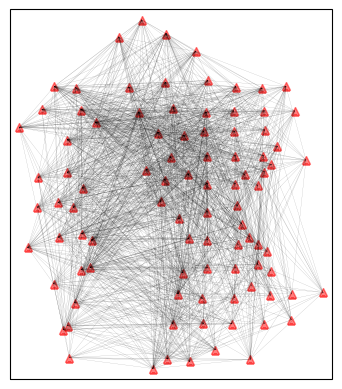

In [6]:
plt.figure()
ax = plt.axes(projection=ccrs.Mercator())
#ax.gridlines(draw_labels=True)
ax.set_extent(map_boundaries)
regular_tomos[0].plot_rays(ax=ax, stations_color='r',
            stations_alpha=0.5, paths_alpha=0.5, paths_width=0.1, show=True)

### 1.2 Ray density for the regular grids

In [7]:
def plot_grid_ray_density(tomo, list_steps, title = "", max_rays = None):
        """Plot ray density
        
        tomo : instance of SeisLib_Tomo.SeismicTomography : tomography the ray density of which to plot
        list_steps : values for which we categorize cells
        """

        size = 5
        fig, axs = plt.subplots(1, 2, figsize = (2*size, size), 
                                subplot_kw = {'projection':ccrs.Mercator()})
        raydensity = tomo.raypaths_per_pixel()

        # Axes 1 : Ray density
        #axs[0].gridlines(draw_labels=True)
        axs[0].set_extent(map_boundaries)
        img = tomo.colormesh(mesh=tomo.grid.mesh, c=raydensity, ax=axs[0], cmap='YlOrRd', shading='flat', 
                            vmin = min_rays, vmax = max_rays, edgecolors='None', alpha=1)
        axs[0].set_extent(map_boundaries)
        cb = make_colorbar(axs[0], img, orientation='horizontal')
        cb.set_label(label='Ray density', labelpad=10)
        axs[0].set_title("Ray density as gradient")

        # Axes 2: Ray density in bins
        #axs[1].gridlines(draw_labels=True)
        axs[1].set_extent(map_boundaries)

        # https://stackoverflow.com/questions/48613920/use-of-extend-in-a-pcolormesh-plot-with-discrete-colorbar
        boundaries = list_steps
        #print(boundaries)
        Ncolors = len(boundaries) - 1 # number of colors
        cmap_YlOrRd = plt.cm.get_cmap("YlOrRd", Ncolors)
        colors = list(cmap_YlOrRd(np.arange(Ncolors)))
        #print(colors)
        cmap = mpl.colors.ListedColormap(colors, "")
        #cmap.set_over(colors[-1])
        #cmap.set_under(colors[0])

        norm = mpl.colors.BoundaryNorm(boundaries, ncolors = Ncolors, clip = True)

        img = tomo.colormesh(mesh=tomo.grid.mesh, c=raydensity, ax=axs[1], cmap = cmap, norm = norm, shading='flat', edgecolors='None', alpha=1)
        axs[1].set_extent(map_boundaries)
        cb = make_colorbar(axs[1], img, orientation='horizontal', norm = norm)
        cb.set_label(label='Ray density', labelpad=10)
        axs[1].set_title("Ray density as bins")
        fig.suptitle(title)
        fig.show()

def plot_grids_ray_density(tomos, titles, title = "", max_rays = None):
        size_list = len(tomos)
        size = 5
        fig, axs = plt.subplots(1, size_list, figsize = (size_list*size, size), 
                                subplot_kw = {'projection':ccrs.Mercator()})
        for i, tomo in enumerate(tomos):
                raydensity = tomo.raypaths_per_pixel()
                axs[i].set_extent(map_boundaries)
                img = tomo.colormesh(mesh=tomo.grid.mesh, c=raydensity, ax=axs[i], cmap='YlOrRd', shading='flat', 
                                vmin = min_rays, vmax = max_rays, edgecolors='None', alpha=1)
                cb = make_colorbar(axs[i], img, orientation='horizontal')
                cb.set_label(label='Ray density', labelpad=10)
                axs[i].set_title(titles[i])
        fig.suptitle(title, fontsize = 16)
        plt.show()

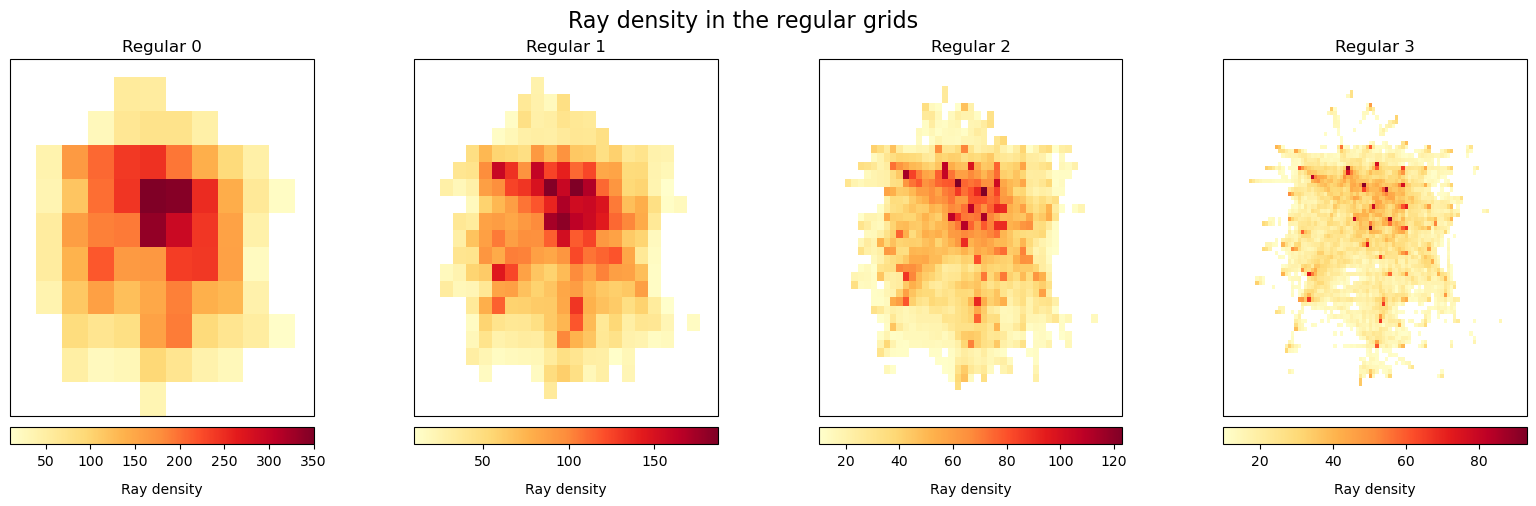

Regular grid 0
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -118.08110 - -117.78110
Latmin - Latmax : 40.14110 - 40.44110
Number of cells : 70
Grid cells of 0.03000° : 70
-------------------------------------

Regular grid 1
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -118.08110 - -117.78110
Latmin - Latmax : 40.15610 - 40.44110
Number of cells : 242
Grid cells of 0.01500° : 242
-------------------------------------

Regular grid 2
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -118.08110 - -117.78860
Latmin - Latmax : 40.16360 - 40.43360
Number of cells : 817
Grid cells of 0.00750° : 817
-------------------------------------

Regular grid 3
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -118.08110 - -117.78860
Latmin - Latmax : 40.16730 - 40.42980
Number of cells : 2276
Grid cells of 0.00375° : 2276
-------------------------------------



In [8]:
# Printing information on each to
index = 0
titles = [f"Regular {i}" for i in range(4)]
title = "Ray density in the regular grids"
plot_grids_ray_density(regular_tomos, titles, title)

for tomo in regular_tomos:
    print(f"Regular grid {index}")
    #plot_grid_ray_density(tomo, map_boundaries, title = "Regular grid")
    print(tomo.grid)
    print()
    index = index + 1

## 1.2 Seislib adaptive grid

In [9]:
tomo_adaptative = create_tomo(np.max(cell_sizes), data_file, station_list)
tomo_adaptative.raypath_number_selection(min_rays)

In [10]:
tomo_adaptative.grid.ncells_per_level[1]

0

In [11]:
tomo_adaptative.grid

-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -118.08110 - -117.78110
Latmin - Latmax : 40.14110 - 40.44110
Number of cells : 70
Grid cells of 0.03000° : 70
-------------------------------------

Refinement step 1 - Previous size : 70, current size : 244
Refinement step 2 - Previous size : 244, current size : 720
Refinement step 3 - Previous size : 720, current size : 1677


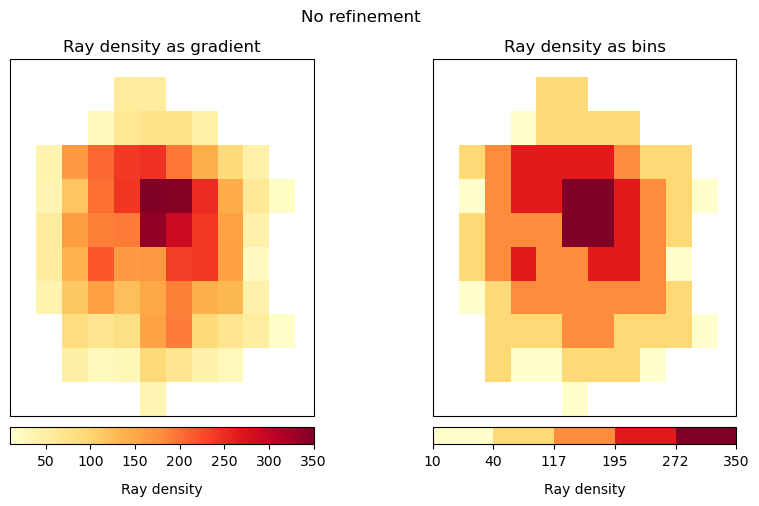

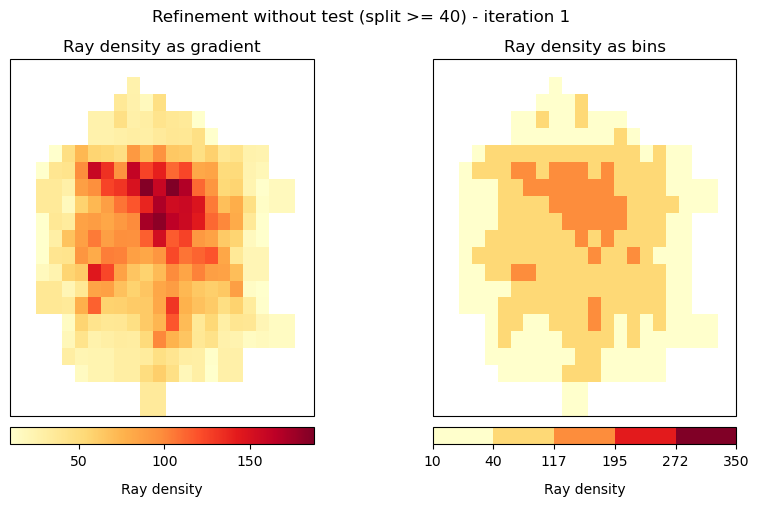

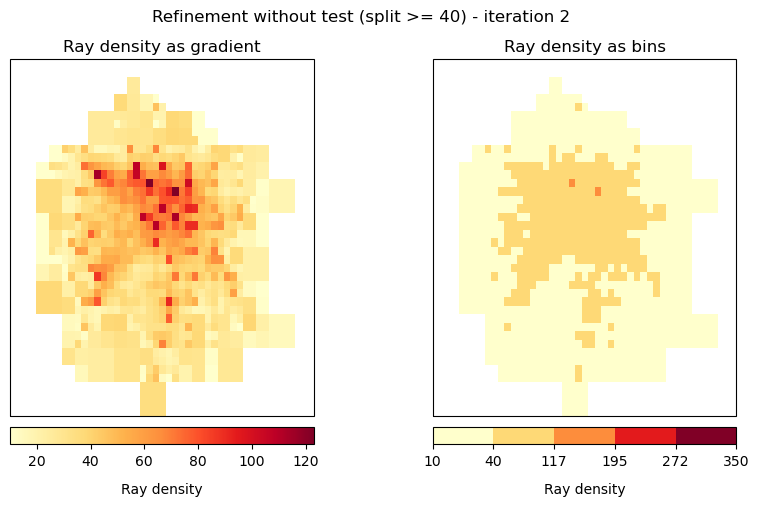

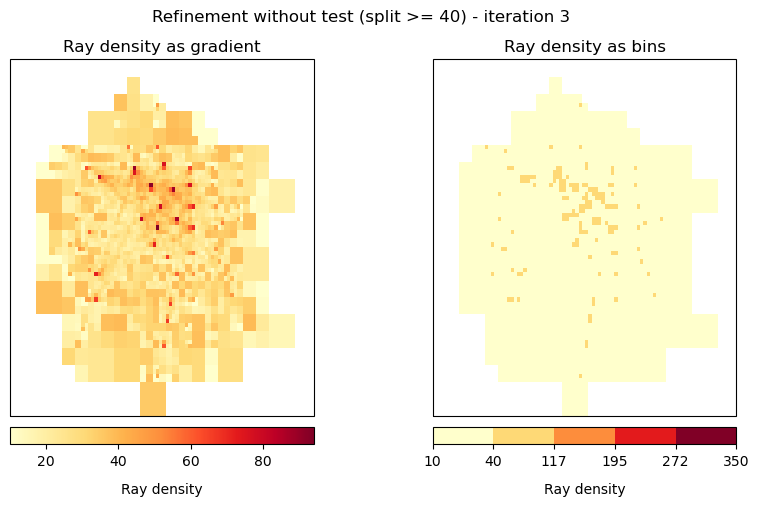

In [12]:
tomo_adaptative = create_tomo(np.max(cell_sizes), data_file, station_list)
tomo_adaptative.compile_coefficients()
tomo_adaptative.raypath_number_selection(min_rays)
plot_grid_ray_density(tomo_adaptative, density_bins, title = "No refinement")
stop_refinement = False
count = 0
while not stop_refinement :
    size_mesh_prev = tomo_adaptative.grid.mesh.shape[0]
    raydensity = tomo_adaptative.raypaths_per_pixel()
    tomo_adaptative.refine_parameterization(refine_step)
    tomo_adaptative.compile_coefficients(coeff_matrix = tomo_adaptative.A, refine = True, keep_empty_cells=False)
    count += 1
    plot_grid_ray_density(tomo_adaptative, density_bins, title = f"Refinement without test (split >= {refine_step}) - iteration {count}")
    print(f"Refinement step {count} - Previous size : {size_mesh_prev}, current size : {tomo_adaptative.grid.mesh.shape[0]}")
    if tomo_adaptative.grid.mesh.shape[0] == size_mesh_prev or count >= max_refine_steps :
        stop_refinement = True
        

## 3. Refinement with test on sub-cells

In [13]:
import tomography_test

def refine_parametrization_w_tests(tomo, hitconts):
    newmesh, A = tomography_test._refine_parameterization_w_tests(tomo.grid.mesh, tomo.A, tomo.data_coords.copy(order='C'), hitcounts=hitconts, region_to_refine=None)
    tomo.grid.update_grid_params(newmesh, refined = True)
    tomo.compile_coefficients(refine = True, coeff_matrix=A, keep_empty_cells=True)

Refinement step 1 - Previous size : 70, current size : 175
Refinement step 2 - Previous size : 175, current size : 343
Refinement step 3 - Previous size : 343, current size : 349


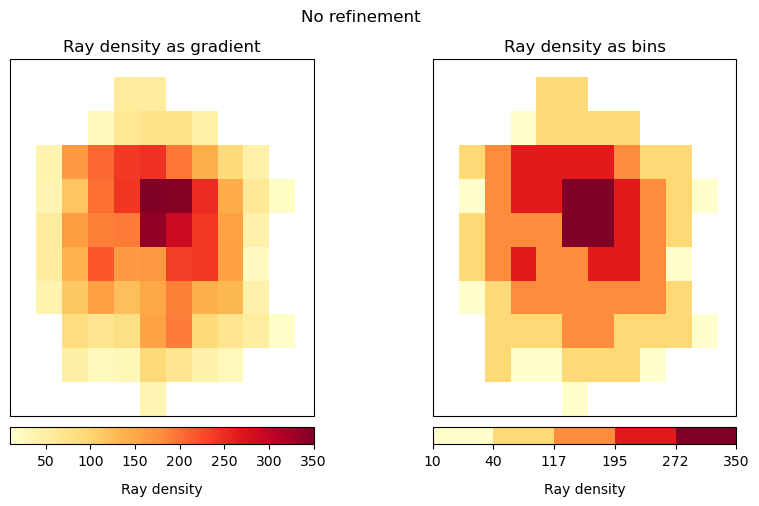

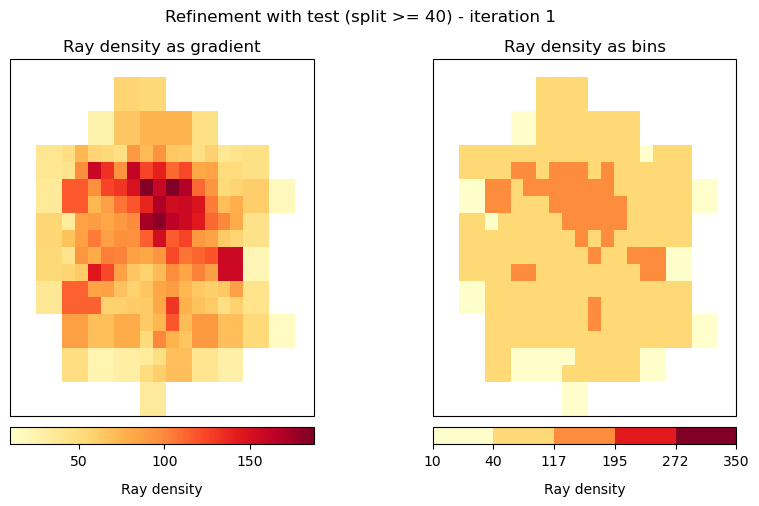

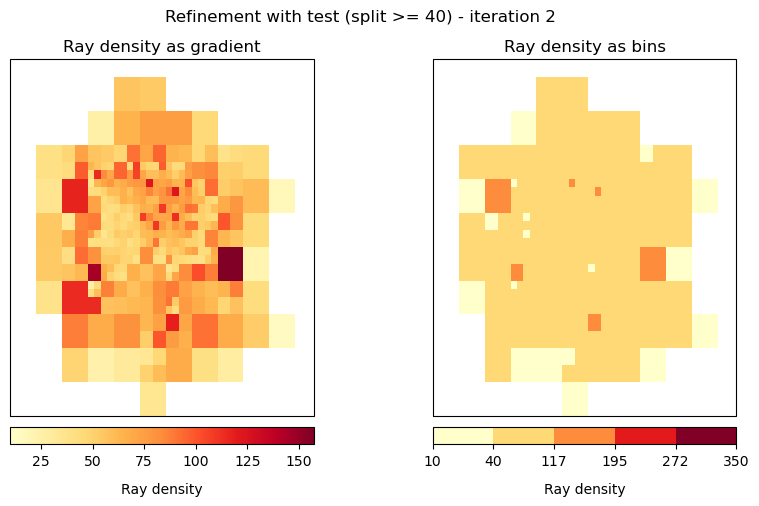

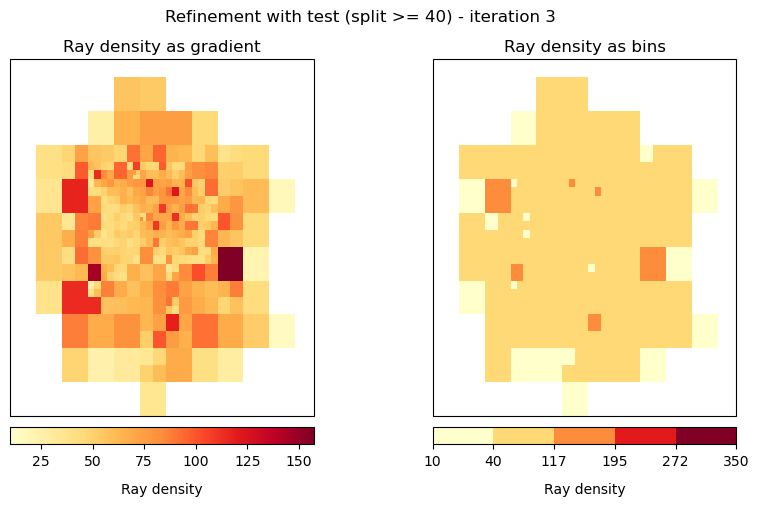

In [16]:
tomo_adaptative_w_test = create_tomo(np.max(cell_sizes), data_file, station_list)
tomo_adaptative_w_test.compile_coefficients()
tomo_adaptative_w_test.raypath_number_selection(min_rays)
plot_grid_ray_density(tomo_adaptative_w_test, density_bins, title = "No refinement")
stop_refinement = False
count = 0
while not stop_refinement :
    size_mesh_prev = tomo_adaptative_w_test.grid.mesh.shape[0]
    raydensity = tomo_adaptative_w_test.raypaths_per_pixel()
    refine_parametrization_w_tests(tomo_adaptative_w_test, refine_step)
    tomo_adaptative_w_test.compile_coefficients(coeff_matrix = tomo_adaptative_w_test.A, refine = True, keep_empty_cells=False)
    count += 1
    plot_grid_ray_density(tomo_adaptative_w_test, density_bins, title = f"Refinement with test (split >= {refine_step}) - iteration {count}")
    print(f"Refinement step {count} - Previous size : {size_mesh_prev}, current size : {tomo_adaptative_w_test.grid.mesh.shape[0]}")
    if tomo_adaptative_w_test.grid.mesh.shape[0] == size_mesh_prev or count >= max_refine_steps :
        stop_refinement = True
        

## 4. Comparison between the adaptive grids

Adaptative grid without test:
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -118.08110 - -117.78110
Latmin - Latmax : 40.14110 - 40.44110
Number of cells : 1677
Grid cells of 0.03000° : 10
Grid cells of 0.01500° : 75
Grid cells of 0.00750° : 316
Grid cells of 0.00375° : 1276
-------------------------------------
------------------------------
Adaptative grid with test:
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -118.08110 - -117.78110
Latmin - Latmax : 40.14110 - 40.44110
Number of cells : 349
Grid cells of 0.03000° : 35
Grid cells of 0.01500° : 84
Grid cells of 0.00750° : 222
Grid cells of 0.00375° : 8
-------------------------------------
------------------------------


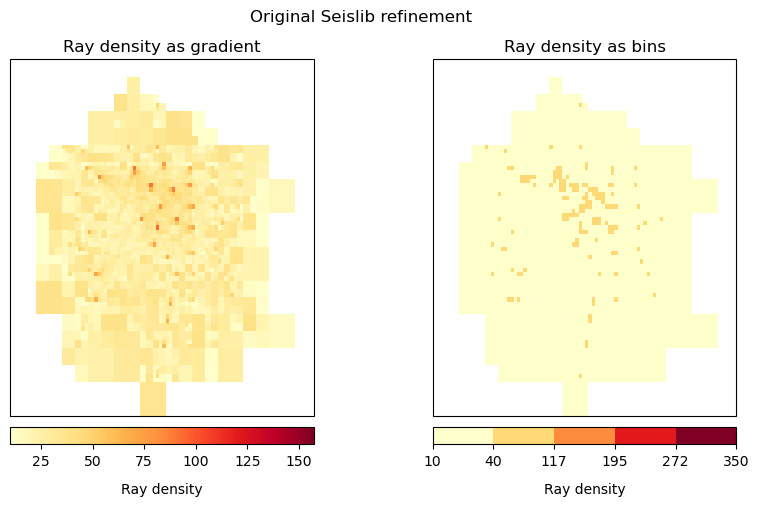

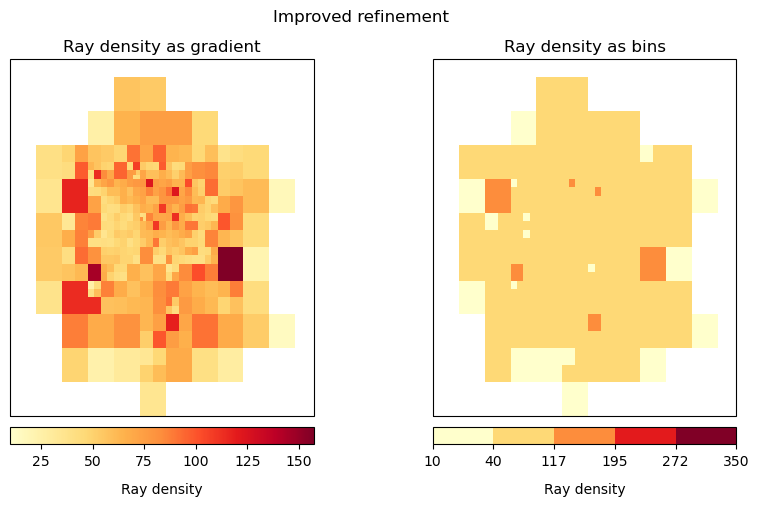

In [19]:
raydensity = tomo_adaptative_w_test.raypaths_per_pixel()
max_value = np.max(raydensity)
print("Adaptative grid without test:")
print(tomo_adaptative.grid)
print("------------------------------")
print("Adaptative grid with test:")
print(tomo_adaptative_w_test.grid)
print("------------------------------")
plot_grid_ray_density(tomo_adaptative, density_bins, max_rays=max_value, title = f"Original Seislib refinement")
plot_grid_ray_density(tomo_adaptative_w_test, density_bins, max_rays=max_value, title = f"Improved refinement")